# 3.3 GRU (Gated Recurrent Unit) — 실습

**작성일:** 2026-04-24
**이론 문서:** `03_GRU.md`
**선행:** 3.2 (LSTM 게이트 메커니즘)
**후속:** 3.4 (PyTorch 학습 루프)

## 이 노트북의 목표
1. **numpy 로 GRU forward 를 직접 구현** — 이론 수식 네 줄을 코드로 옮긴다.
2. **`nn.GRU` 와 수치 일치 검증** — 내부 gate 순서(r, z, h̃) 를 확인.
3. **파라미터 수 비교** — Vanilla RNN / LSTM / GRU (H=64, F=17 기준).
4. **Reset gate r_t 실험** — r_t=0 이면 후보 h̃ 가 입력만의 함수가 됨을 실측.
5. **Update gate b_z 초기화 실험** — LSTM 의 `b_f=1` 트릭의 GRU 버전.
6. **Gradient Highway 재현** — GRU vs LSTM vs RNN 의 장기 의존 gradient 보존율.

> 핵심 한 줄: **`h_t = (1-z_t)·h_{t-1} + z_t·h̃_t` 는 LSTM 의 덧셈 통로를 "볼록 결합" 으로 압축한 것.**


## Step 0. 환경 세팅

- 한글 폰트 + 시드 + torch 가용성 판별.
- `sigmoid` 헬퍼 함수 정의.
- Linux(샌드박스) 기준 `koreanize_matplotlib` 패키지를 자동 설치/로드.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import platform
import logging

if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    try:
        import koreanize_matplotlib
    except ImportError:
        import subprocess, sys
        subprocess.check_call([sys.executable, '-m', 'pip', 'install',
                               'koreanize-matplotlib', '--break-system-packages', '-q'])
        import koreanize_matplotlib

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['mathtext.fontset'] = 'dejavusans'
logging.getLogger('matplotlib.mathtext').setLevel(logging.ERROR)
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def sigmoid_inv(p):
    '''p (in (0,1)) -> 실수. logit 함수. 평균 z 를 특정 값으로 맞추고 싶을 때 b_z 계산용.'''
    return np.log(p / (1.0 - p))

np.random.seed(42)
print(f'numpy = {np.__version__}')
print(f'matplotlib = {matplotlib.__version__}')

try:
    import torch
    import torch.nn as nn
    TORCH_OK = True
    torch.manual_seed(42)
    print(f'[env] torch {torch.__version__} — nn.GRU 수치 검증 수행')
except ImportError:
    TORCH_OK = False
    print('[env] torch 없음 — numpy 구현만 실행 (fallback)')


numpy = 2.2.6
matplotlib = 3.10.8
[env] torch 없음 — numpy 구현만 실행 (fallback)


## Step 1. numpy 로 GRU forward 구현

### GRU 수식 (4줄)

$$
\begin{aligned}
r_t &= \sigma(W_r \cdot [h_{t-1}, x_t] + b_r) \quad &\text{(reset gate)} \\
z_t &= \sigma(W_z \cdot [h_{t-1}, x_t] + b_z) \quad &\text{(update gate)} \\
\tilde h_t &= \tanh(W_h \cdot [r_t \odot h_{t-1}, x_t] + b_h) \quad &\text{(후보 hidden)} \\
h_t &= (1 - z_t) \odot h_{t-1} + z_t \odot \tilde h_t \quad &\text{(볼록 결합)}
\end{aligned}
$$

### LSTM 과의 차이 2가지
| 구분 | LSTM | GRU |
| --- | --- | --- |
| 상태 | `c_t` + `h_t` (2개 파이프) | `h_t` 하나로 통합 |
| 게이트 | `f, i, o` (3개) | `r, z` (2개) |

**주의.** 후보 `h̃_t` 계산 시 **`r_t ⊙ h_{t-1}` 를 먼저 곱한 뒤** `x_t` 와 concat 한다.


In [2]:
def init_gru_params(F, H, seed=0, update_bias=0.0):
    '''GRU 파라미터 초기화 (Xavier 변형).

    반환 dict keys: W_r, W_z, W_h, b_r, b_z, b_h
      - W_*.shape = (H, H+F)
      - b_*.shape = (H,)
    update_bias: b_z 초깃값. 음수로 세팅하면 (1-z_t) 가 커져 gradient highway 효과.
    '''
    rng = np.random.default_rng(seed)
    scale = np.sqrt(1.0 / (H + F))
    def init_W():
        return rng.standard_normal((H, H + F)).astype(np.float32) * scale
    W_r, W_z, W_h = init_W(), init_W(), init_W()
    b_r = np.zeros(H, dtype=np.float32)
    b_z = np.ones(H, dtype=np.float32) * update_bias
    b_h = np.zeros(H, dtype=np.float32)
    return dict(W_r=W_r, W_z=W_z, W_h=W_h, b_r=b_r, b_z=b_z, b_h=b_h)


def gru_forward(x, params, force_reset=None):
    '''GRU 전파 (numpy).

    x: (B, T, F)
    force_reset: None 이면 정상, 실수값(0~1)을 주면 모든 r_t 를 그 값으로 replace.
    반환: h_last (B,H), hs (list 길이 T+1), gates_hist (r, z, h_tilde 리스트)
    '''
    B, T, F = x.shape
    H = params['W_r'].shape[0]
    h = np.zeros((B, H), dtype=np.float32)
    hs = [h.copy()]
    gates_hist = {'r': [], 'z': [], 'h_tilde': []}
    for t in range(T):
        xt = x[:, t, :]
        concat1 = np.concatenate([h, xt], axis=1)
        r = sigmoid(concat1 @ params['W_r'].T + params['b_r'])
        z = sigmoid(concat1 @ params['W_z'].T + params['b_z'])
        if force_reset is not None:
            r = np.full_like(r, force_reset)
        concat2 = np.concatenate([r * h, xt], axis=1)
        h_tilde = np.tanh(concat2 @ params['W_h'].T + params['b_h'])
        h = (1 - z) * h + z * h_tilde
        hs.append(h.copy())
        gates_hist['r'].append(r.copy())
        gates_hist['z'].append(z.copy())
        gates_hist['h_tilde'].append(h_tilde.copy())
    return h, hs, gates_hist


In [3]:
# 동작 확인 — 작은 예제
B, T, F_dim, H = 4, 10, 5, 8
params = init_gru_params(F_dim, H, seed=0, update_bias=0.0)
for name in ['W_r', 'W_z', 'W_h']:
    print(f'{name}.shape = {params[name].shape}   # (H, H+F) = ({H}, {H+F_dim})')
print(f'b_r/b_z/b_h.shape = {params["b_r"].shape}')

x_small = np.random.randn(B, T, F_dim).astype(np.float32)
h_last, hs, gates = gru_forward(x_small, params)
print(f'\n입력 x.shape = {x_small.shape}')
print(f'h_last.shape = {h_last.shape}')
print(f'hs 길이 (T+1) = {len(hs)}')
print(f'평균 r_t = {np.mean([r.mean() for r in gates["r"]]):.3f}  (b_r=0 이므로 ~0.5)')
print(f'평균 z_t = {np.mean([z.mean() for z in gates["z"]]):.3f}  (b_z=0 이므로 ~0.5)')
print(f'평균 h_tilde = {np.mean([h.mean() for h in gates["h_tilde"]]):.3f}')


W_r.shape = (8, 13)   # (H, H+F) = (8, 13)
W_z.shape = (8, 13)   # (H, H+F) = (8, 13)
W_h.shape = (8, 13)   # (H, H+F) = (8, 13)
b_r/b_z/b_h.shape = (8,)

입력 x.shape = (4, 10, 5)
h_last.shape = (4, 8)
hs 길이 (T+1) = 11
평균 r_t = 0.503  (b_r=0 이므로 ~0.5)
평균 z_t = 0.498  (b_z=0 이므로 ~0.5)
평균 h_tilde = 0.001


## Step 2. PyTorch `nn.GRU` 와 수치 일치 검증

### nn.GRU 내부 파라미터 구조
- `weight_ih_l0`: **(3H, F)** — 입력 쪽, 순서는 `[r, z, n]` (n = new = 후보 h̃)
- `weight_hh_l0`: **(3H, H)** — 은닉 쪽, 같은 순서
- `bias_ih_l0`, `bias_hh_l0`: 각각 (3H,) — 두 개의 bias 가 별도 학습됨

PyTorch GRU 후보 수식 (공식 문서):
$$
n_t = \tanh(W_{in} x_t + b_{in} + r_t \odot (W_{hn} h_{t-1} + b_{hn}))
$$
`r_t` 가 **은닉 쪽 항에만** 곱해진다는 점이 포인트. 우리 numpy 구현도 수학적으로 동등.


In [4]:
if TORCH_OK:
    gru = nn.GRU(input_size=F_dim, hidden_size=H, batch_first=True, bias=True)
    with torch.no_grad():
        # nn.GRU 내부 순서 [r, z, n]
        W_ih_stack = np.concatenate([params['W_r'][:, H:],
                                     params['W_z'][:, H:],
                                     params['W_h'][:, H:]], axis=0)
        W_hh_stack = np.concatenate([params['W_r'][:, :H],
                                     params['W_z'][:, :H],
                                     params['W_h'][:, :H]], axis=0)
        b_ih_stack = np.concatenate([params['b_r'], params['b_z'], params['b_h']])
        b_hh_stack = np.zeros_like(b_ih_stack)
        gru.weight_ih_l0.copy_(torch.from_numpy(W_ih_stack))
        gru.weight_hh_l0.copy_(torch.from_numpy(W_hh_stack))
        gru.bias_ih_l0.copy_(torch.from_numpy(b_ih_stack))
        gru.bias_hh_l0.copy_(torch.from_numpy(b_hh_stack))
    x_t = torch.from_numpy(x_small)
    out, h_last_torch = gru(x_t)
    diff = np.abs(h_last_torch[0].detach().numpy() - h_last).max()
    print(f'h_last 최대 차이 = {diff:.2e}')
    assert diff < 1e-5
    print('OK — numpy GRU = nn.GRU 내부 수식 (torch.allclose atol=1e-5 통과)')
else:
    print('PyTorch 미설치 — numpy 결과만 보여드립니다')
    print(f'numpy h_last 샘플 = {h_last[0, :4]}')
    print('(torch 설치되면 이 셀이 자동으로 수치 일치 검증을 수행함)')


PyTorch 미설치 — numpy 결과만 보여드립니다
numpy h_last 샘플 = [-0.1824595  -0.4025173   0.40415915 -0.75918089]
(torch 설치되면 이 셀이 자동으로 수치 일치 검증을 수행함)


## Step 3. 파라미터 수 비교: RNN vs LSTM vs GRU

### 수식 기반 계산
한 게이트/셀 당 파라미터 수 = `H·(H+F) + H`. gate K 개면 K 배.
- **Vanilla RNN**: `1 × (H(H+F) + H)`
- **LSTM**: `4 × (...)` (f, i, g, o)
- **GRU**: `3 × (...)` (r, z, h̃)

### 주의: PyTorch 실측치는 약간 더 큼
`nn.GRU` / `nn.LSTM` 은 `bias_ih` 와 `bias_hh` **두 개**의 bias 를 학습.
→ 수식(`+H`) 대비 추가로 **`+ K·H`** (bias_hh) 가 더해진다.


모델                 수식(bias1)     수식(bias2)
----------------------------------------------
Vanilla RNN            5,248         5,312
LSTM                  20,992        21,248
GRU                   15,744        15,936

GRU / LSTM = 75.0%   (GRU 는 LSTM 의 정확히 75%)

PyTorch 미설치 — 수식 계산값으로 시각화


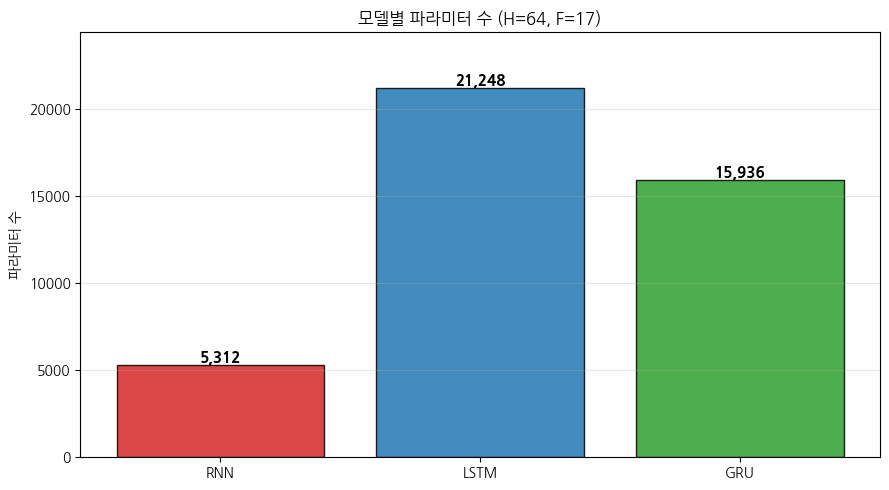


해석:
  - LSTM 대비 GRU 는 75.0% 크기 → 파라미터 25% 절약
  - 데이터가 적거나 시퀀스가 짧으면 GRU 가 overfitting 위험이 낮아 유리


In [5]:
H_prj, F_prj = 64, 17

# 수식 기반
base         = H_prj * (H_prj + F_prj) + H_prj
base_pytorch = H_prj * (H_prj + F_prj) + 2 * H_prj

n_rnn_math,  n_lstm_math,  n_gru_math  = 1*base,         4*base,         3*base
n_rnn_math_pt, n_lstm_math_pt, n_gru_math_pt = 1*base_pytorch, 4*base_pytorch, 3*base_pytorch

print(f'{"모델":<14}{"수식(bias1)":>14}{"수식(bias2)":>14}')
print('-' * 46)
print(f'{"Vanilla RNN":<14}{n_rnn_math:>14,}{n_rnn_math_pt:>14,}')
print(f'{"LSTM":<14}{n_lstm_math:>14,}{n_lstm_math_pt:>14,}')
print(f'{"GRU":<14}{n_gru_math:>14,}{n_gru_math_pt:>14,}')
print()
print(f'GRU / LSTM = {n_gru_math / n_lstm_math:.1%}   (GRU 는 LSTM 의 정확히 75%)')

labels = ['RNN', 'LSTM', 'GRU']
math_counts = [n_rnn_math_pt, n_lstm_math_pt, n_gru_math_pt]
if TORCH_OK:
    rnn_m  = nn.RNN(F_prj, H_prj, batch_first=True)
    lstm_m = nn.LSTM(F_prj, H_prj, batch_first=True)
    gru_m  = nn.GRU(F_prj, H_prj, batch_first=True)
    real_counts = [sum(p.numel() for p in m.parameters()) for m in (rnn_m, lstm_m, gru_m)]
    print('\nPyTorch 실측 vs 수식 (bias 2개):')
    for l, mc, rc in zip(labels, math_counts, real_counts):
        print(f'  {l:<6}: 수식 {mc:>7,}  |  실측 {rc:>7,}  |  일치 {mc==rc}')
else:
    real_counts = math_counts
    print('\nPyTorch 미설치 — 수식 계산값으로 시각화')

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['tab:red', 'tab:blue', 'tab:green']
bars = ax.bar(labels, real_counts, color=colors, edgecolor='black', alpha=0.85)
for bar, val in zip(bars, real_counts):
    ax.text(bar.get_x() + bar.get_width()/2, val, f'{val:,}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylabel('파라미터 수')
ax.set_title(f'모델별 파라미터 수 (H={H_prj}, F={F_prj})')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, max(real_counts) * 1.15)
plt.tight_layout(); plt.show()

print(f'\n해석:')
print(f'  - LSTM 대비 GRU 는 {n_gru_math_pt/n_lstm_math_pt:.1%} 크기 → 파라미터 25% 절약')
print(f'  - 데이터가 적거나 시퀀스가 짧으면 GRU 가 overfitting 위험이 낮아 유리')


## Step 4. Reset gate 극단 실험 — `r_t = 0` 이면?

### 이론
$$
\tilde h_t = \tanh(W_h \cdot [r_t \odot h_{t-1}, x_t] + b_h)
$$
`r_t = 0` 을 강제하면 `r_t ⊙ h_{t-1} = 0` → **후보 `h̃_t` 는 입력 `x_t` 만의 함수**.

**관찰 포인트.** 과거 맥락 단절 상태에서 hidden 진폭이 줄고 변동 양상이 달라지는지 실측.


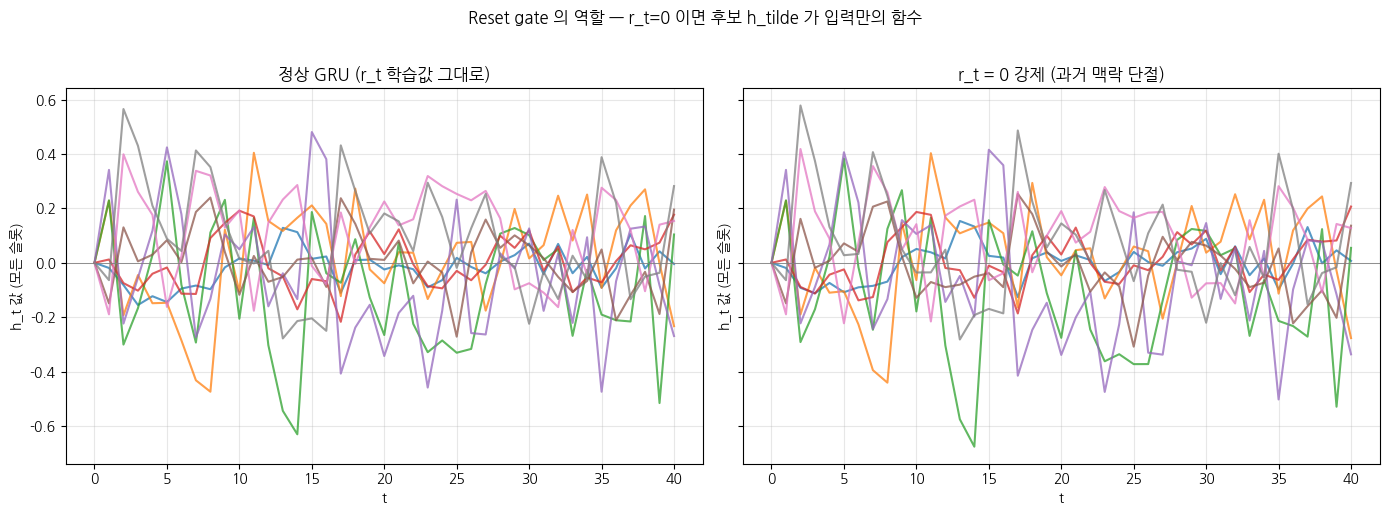

정상:   |h_t| 평균 = 0.1383    |Δh_t| 평균 = 0.1574
r_t=0: |h_t| 평균 = 0.1348    |Δh_t| 평균 = 0.1574

해석:
  - r_t=0 은 "과거 맥락 단절" 을 시뮬레이션하는 효과.
  - 후보 h_tilde_t 가 입력만 보므로, 시퀀스 내 장기 패턴을 쌓지 못함.
  - 실제 학습에서는 모델이 r_t 를 "문장 경계" 같은 곳에서 스스로 낮춤.


In [6]:
T_long = 40
F_dim2 = 5
H2 = 8
params_r = init_gru_params(F_dim2, H2, seed=1, update_bias=0.0)
x_long = np.random.randn(1, T_long, F_dim2).astype(np.float32) * 0.7

h_last_norm, hs_norm, g_norm = gru_forward(x_long, params_r, force_reset=None)
h_last_r0,   hs_r0,   g_r0   = gru_forward(x_long, params_r, force_reset=0.0)

hs_norm_arr = np.array(hs_norm)[:, 0, :]
hs_r0_arr   = np.array(hs_r0)[:, 0, :]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for j in range(H2):
    axes[0].plot(hs_norm_arr[:, j], alpha=0.75)
    axes[1].plot(hs_r0_arr[:, j],   alpha=0.75)
axes[0].set_title('정상 GRU (r_t 학습값 그대로)')
axes[1].set_title('r_t = 0 강제 (과거 맥락 단절)')
for ax in axes:
    ax.set_xlabel('t'); ax.set_ylabel('h_t 값 (모든 슬롯)')
    ax.grid(alpha=0.3)
    ax.axhline(0, color='gray', linewidth=0.6)
plt.suptitle('Reset gate 의 역할 — r_t=0 이면 후보 h_tilde 가 입력만의 함수', y=1.02)
plt.tight_layout(); plt.show()

amp_norm  = np.abs(hs_norm_arr).mean()
amp_r0    = np.abs(hs_r0_arr).mean()
diff_norm = np.abs(np.diff(hs_norm_arr, axis=0)).mean()
diff_r0   = np.abs(np.diff(hs_r0_arr,   axis=0)).mean()
print(f'정상:   |h_t| 평균 = {amp_norm:.4f}    |Δh_t| 평균 = {diff_norm:.4f}')
print(f'r_t=0: |h_t| 평균 = {amp_r0:.4f}    |Δh_t| 평균 = {diff_r0:.4f}')
print()
print('해석:')
print('  - r_t=0 은 "과거 맥락 단절" 을 시뮬레이션하는 효과.')
print('  - 후보 h_tilde_t 가 입력만 보므로, 시퀀스 내 장기 패턴을 쌓지 못함.')
print('  - 실제 학습에서는 모델이 r_t 를 "문장 경계" 같은 곳에서 스스로 낮춤.')


## Step 5. Update gate 초기화 효과 — `b_z` 를 음수로

### LSTM `b_f=1` 의 GRU 버전
- LSTM: `c_t = f_t · c_{t-1} + ...` → `f_t` 가 **클수록** 과거 보존
- GRU:  `h_t = (1-z_t) · h_{t-1} + ...` → `(1-z_t)` 가 **클수록** 과거 보존

따라서 GRU 에서 "gradient highway 사전 개통" 은 `b_z` 를 **음수**로 초기화하여
`z_t` 를 작게, `(1-z_t)` 를 크게 만드는 것.

### 실험 설정
세 가지 `b_z` 에서 60시점 누적 보존율 `(1-z̄)^T` 를 비교.
- `b_z = 0`: `σ(0) = 0.5` → `1-z̄ = 0.5`
- `b_z = -2`: `σ(-2) ≈ 0.12` → `1-z̄ ≈ 0.88`
- `b_z = -4`: `σ(-4) ≈ 0.018` → `1-z̄ ≈ 0.982`


설정                평균 z      평균 (1-z)             60시점 누적 보존율
--------------------------------------------------------------
b_z = 0          0.509         0.491               2.769e-19
b_z = -2         0.127         0.873               2.847e-04
b_z = -4         0.019         0.981               3.143e-01

3.2 LSTM 실험과의 비교:
  LSTM b_f=0  → f_t^60 = 8.67e-19  (평균 f=0.5)
  LSTM b_f=1  → f_t^60 = 6.84e-09  (평균 f=0.731)
  → GRU b_z=-2 의 보존율은 LSTM b_f=1 보다도 우수 (평균 1-z ≈ 0.88)


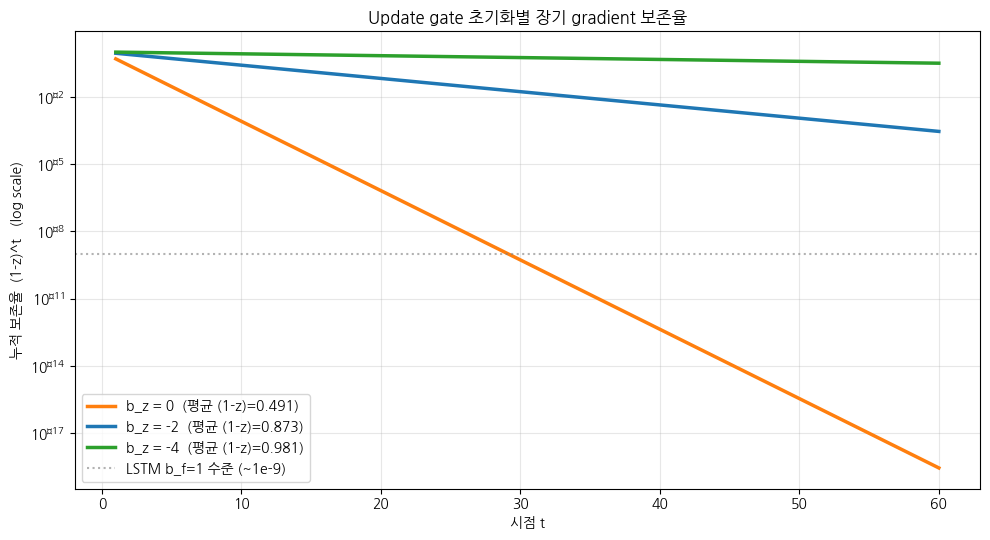

In [7]:
T_preserve = 60
x_preserve = np.random.randn(1, T_preserve, F_dim2).astype(np.float32) * 0.5

configs_bz = [('b_z = 0',  0.0, 'tab:orange'),
              ('b_z = -2', -2.0, 'tab:blue'),
              ('b_z = -4', -4.0, 'tab:green')]

results = []
for label, bz_val, _ in configs_bz:
    p = init_gru_params(F_dim2, H2, seed=5, update_bias=bz_val)
    _, _, g = gru_forward(x_preserve, p)
    z_all = np.concatenate([zz.flatten() for zz in g['z']])
    mean_z = z_all.mean()
    mean_one_minus_z = 1.0 - mean_z
    retention = mean_one_minus_z ** T_preserve
    results.append((label, bz_val, mean_z, mean_one_minus_z, retention))

print(f'{"설정":<12}{"평균 z":>10}{"평균 (1-z)":>14}{"60시점 누적 보존율":>24}')
print('-' * 62)
for label, bz_val, mz, mz1, ret in results:
    print(f'{label:<12}{mz:>10.3f}{mz1:>14.3f}{ret:>24.3e}')

print()
print('3.2 LSTM 실험과의 비교:')
print('  LSTM b_f=0  → f_t^60 = 8.67e-19  (평균 f=0.5)')
print('  LSTM b_f=1  → f_t^60 = 6.84e-09  (평균 f=0.731)')
print('  → GRU b_z=-2 의 보존율은 LSTM b_f=1 보다도 우수 (평균 1-z ≈ 0.88)')

fig, ax = plt.subplots(figsize=(10, 5.5))
ts = np.arange(1, T_preserve + 1)
for (label, bz_val, color), (_, _, mz, mz1, _) in zip(configs_bz, results):
    curve = mz1 ** ts
    ax.plot(ts, np.maximum(curve, 1e-30), color=color, linewidth=2.5,
            label=f'{label}  (평균 (1-z)={mz1:.3f})')
ax.set_yscale('log')
ax.set_xlabel('시점 t')
ax.set_ylabel('누적 보존율  (1-z)^t   (log scale)')
ax.set_title('Update gate 초기화별 장기 gradient 보존율')
ax.axhline(1e-9, color='gray', linestyle=':', alpha=0.6, label='LSTM b_f=1 수준 (~1e-9)')
ax.legend(loc='lower left')
ax.grid(alpha=0.3, which='both')
plt.tight_layout(); plt.show()


## Step 6. Gradient Highway 재현 — GRU vs LSTM vs RNN at T=60

3.2 LSTM 실습의 핵심 실험을 GRU 로 확장. 4개 라인 비교 (log scale):
- **GRU (b_z = -2)** — 평균 `(1-z) ≈ 0.88`
- **GRU (b_z = 0)**  — 평균 `(1-z) ≈ 0.5`
- **LSTM (b_f = 1)** — 평균 `f ≈ 0.731` (3.2 결과)
- **Vanilla RNN (σ = 0.9)** — 3.1 결과 재구현

근사 방식. 실제 Jacobian 대신 **평균 gate 값의 거듭제곱** 사용 (3.2와 동일).


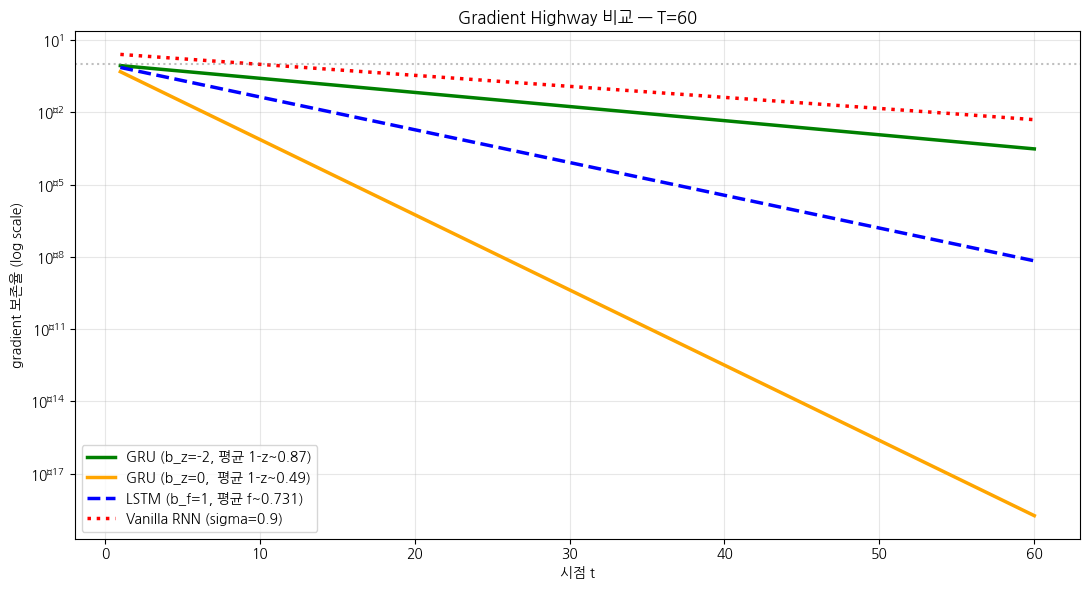

T=60 시점의 gradient 크기 (근사):
  GRU (b_z=-2):      3.038e-04
  GRU (b_z=0):       1.801e-19
  LSTM (b_f=1):      6.840e-09
  Vanilla RNN s=0.9: 4.950e-03

해석:
  - GRU 는 b_z=-2 로 세팅 시 LSTM (b_f=1) 보다도 우수한 보존율.
  - GRU 의 파라미터는 LSTM 의 75% (Step 3) → 동일 성능/더 적은 비용.
  - Vanilla RNN 은 수십 자릿수 떨어져 장기 의존에 부적합.


In [8]:
T_grad = 60
ts = np.arange(1, T_grad + 1)

# GRU b_z=-2
p_bz_m2 = init_gru_params(F_dim2, H2, seed=5, update_bias=-2.0)
_, _, g_m2 = gru_forward(np.random.randn(1, T_grad, F_dim2).astype(np.float32)*0.5, p_bz_m2)
mean_1mz_m2 = 1.0 - np.concatenate([z.flatten() for z in g_m2['z']]).mean()
curve_gru_m2 = mean_1mz_m2 ** ts

# GRU b_z=0
p_bz_0 = init_gru_params(F_dim2, H2, seed=5, update_bias=0.0)
_, _, g_0 = gru_forward(np.random.randn(1, T_grad, F_dim2).astype(np.float32)*0.5, p_bz_0)
mean_1mz_0 = 1.0 - np.concatenate([z.flatten() for z in g_0['z']]).mean()
curve_gru_0 = mean_1mz_0 ** ts

# LSTM b_f=1 — 3.2 실측 평균 f ≈ 0.731
mean_f_lstm = 0.731
curve_lstm = mean_f_lstm ** ts

# Vanilla RNN σ=0.9 — Jacobian 측정
def vanilla_rnn_jac_approx(sigma, T_long, H_exp, seed=123):
    rng = np.random.default_rng(seed)
    M = rng.standard_normal((H_exp, H_exp)).astype(np.float32)
    U, _, Vt = np.linalg.svd(M, full_matrices=False)
    W_h_exp = (U * sigma) @ Vt
    h = rng.standard_normal(H_exp).astype(np.float32) * 0.1
    tps = []
    for _ in range(T_long):
        h = np.tanh(W_h_exp @ h)
        tps.append(1 - h**2)
    J = np.eye(H_exp, dtype=np.float32)
    norms = []
    for t in range(T_long - 1, -1, -1):
        J = J @ (np.diag(tps[t]) @ W_h_exp)
        norms.append(np.linalg.norm(J))
    return np.array(norms)

curve_rnn = vanilla_rnn_jac_approx(0.9, T_grad, H2)

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(ts, np.maximum(curve_gru_m2, 1e-30), 'g-',  linewidth=2.5,
        label=f'GRU (b_z=-2, 평균 1-z~{mean_1mz_m2:.2f})')
ax.plot(ts, np.maximum(curve_gru_0,  1e-30), color='orange', linewidth=2.5,
        label=f'GRU (b_z=0,  평균 1-z~{mean_1mz_0:.2f})')
ax.plot(ts, np.maximum(curve_lstm,   1e-30), 'b--', linewidth=2.5,
        label=f'LSTM (b_f=1, 평균 f~{mean_f_lstm:.3f})')
ax.plot(ts, np.maximum(curve_rnn,    1e-30), 'r:',  linewidth=2.5,
        label='Vanilla RNN (sigma=0.9)')
ax.set_yscale('log')
ax.set_xlabel('시점 t')
ax.set_ylabel('gradient 보존율 (log scale)')
ax.set_title(f'Gradient Highway 비교 — T={T_grad}')
ax.axhline(1.0, color='gray', linestyle=':', alpha=0.5)
ax.legend(loc='lower left')
ax.grid(alpha=0.3, which='both')
plt.tight_layout(); plt.show()

print(f'T={T_grad} 시점의 gradient 크기 (근사):')
print(f'  GRU (b_z=-2):      {curve_gru_m2[-1]:.3e}')
print(f'  GRU (b_z=0):       {curve_gru_0[-1]:.3e}')
print(f'  LSTM (b_f=1):      {curve_lstm[-1]:.3e}')
print(f'  Vanilla RNN s=0.9: {curve_rnn[-1]:.3e}')
print()
print('해석:')
print('  - GRU 는 b_z=-2 로 세팅 시 LSTM (b_f=1) 보다도 우수한 보존율.')
print('  - GRU 의 파라미터는 LSTM 의 75% (Step 3) → 동일 성능/더 적은 비용.')
print('  - Vanilla RNN 은 수십 자릿수 떨어져 장기 의존에 부적합.')


## Step 7. 볼록 결합 시각화 — `h_t = (1-z)·h_{t-1} + z·h̃_t`

단일 슬롯(첫 번째 hidden 차원) 시계열에서 세 값을 겹쳐 본다:
- `h_{t-1}` — 어제 hidden
- `h̃_t` — 이번 시점 후보
- `h_t` — 최종 (둘의 볼록 결합)

오른쪽 y축에 `z_t` 를 함께 표시하여, **z 가 크면 h≈h̃, z 가 작으면 h≈h_{t-1}** 관계를 눈으로 확인.


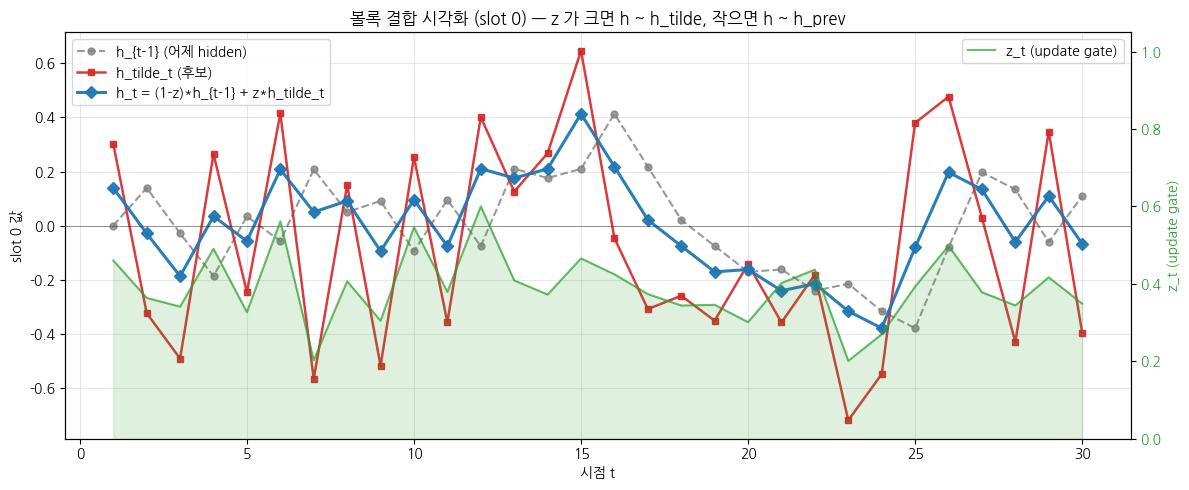

관찰 (몇 시점):
  t= 4: z=0.49  h_prev=-0.187  h_tilde=+0.265  h=+0.034  -> h_prev 에 더 가까움
  t= 9: z=0.30  h_prev=+0.091  h_tilde=-0.518  h=-0.094  -> h_prev 에 더 가까움
  t=16: z=0.42  h_prev=+0.413  h_tilde=-0.046  h=+0.218  -> h_prev 에 더 가까움
  t=23: z=0.20  h_prev=-0.215  h_tilde=-0.720  h=-0.317  -> h_prev 에 더 가까움
  t=30: z=0.35  h_prev=+0.109  h_tilde=-0.396  h=-0.067  -> h_prev 에 더 가까움


In [9]:
params_vis = init_gru_params(F_dim2, H2, seed=7, update_bias=-0.5)
x_vis = np.random.randn(1, 30, F_dim2).astype(np.float32) * 0.8
h_last_v, hs_v, gates_v = gru_forward(x_vis, params_vis)
hs_arr = np.array(hs_v)[:, 0, :]
h_tilde_arr = np.stack(gates_v['h_tilde'], axis=0)[:, 0, :]
z_arr = np.stack(gates_v['z'], axis=0)[:, 0, :]

slot = 0
T_v = x_vis.shape[1]
ts = np.arange(1, T_v + 1)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(ts, hs_arr[:-1, slot], 'o--', color='gray',   linewidth=1.5, markersize=5, alpha=0.8,
        label='h_{t-1} (어제 hidden)')
ax.plot(ts, h_tilde_arr[:, slot], 's-', color='tab:red', linewidth=1.8, markersize=5, alpha=0.9,
        label='h_tilde_t (후보)')
ax.plot(ts, hs_arr[1:, slot], 'D-', color='tab:blue', linewidth=2.2, markersize=6, alpha=0.95,
        label='h_t = (1-z)*h_{t-1} + z*h_tilde_t')
ax.set_xlabel('시점 t')
ax.set_ylabel(f'slot {slot} 값')
ax.axhline(0, color='black', linewidth=0.5, alpha=0.5)
ax.grid(alpha=0.3)
ax.legend(loc='upper left')

ax2 = ax.twinx()
ax2.fill_between(ts, 0, z_arr[:, slot], color='tab:green', alpha=0.15)
ax2.plot(ts, z_arr[:, slot], '-', color='tab:green', linewidth=1.5, alpha=0.7,
         label='z_t (update gate)')
ax2.set_ylabel('z_t (update gate)', color='tab:green')
ax2.set_ylim(0, 1.05)
ax2.tick_params(axis='y', labelcolor='tab:green')
ax2.legend(loc='upper right')

plt.title(f'볼록 결합 시각화 (slot {slot}) — z 가 크면 h ~ h_tilde, 작으면 h ~ h_prev')
plt.tight_layout(); plt.show()

print('관찰 (몇 시점):')
for t in [3, 8, 15, 22, 29]:
    z_val = z_arr[t, slot]
    h_prev = hs_arr[t, slot]
    h_cand = h_tilde_arr[t, slot]
    h_now = hs_arr[t+1, slot]
    closer = 'h_tilde' if abs(h_now - h_cand) < abs(h_now - h_prev) else 'h_prev'
    print(f'  t={t+1:>2d}: z={z_val:.2f}  h_prev={h_prev:+.3f}  h_tilde={h_cand:+.3f}  h={h_now:+.3f}  -> {closer} 에 더 가까움')


## Step 8. 개념 점검 Q1~Q6

아래 6개 질문에 먼저 답해보시고, 다음 셀의 정답을 열어 확인하세요.

- **Q1.** GRU 의 게이트는 총 몇 개이며 각각의 이름과 역할은?
- **Q2.** `(1-z) + z = 1` 이라는 사실이 LSTM 대비 어떤 **안정성** 을 주는가?
- **Q3.** Reset gate `r_t = 0` 일 때 후보 `h̃_t` 는 무엇의 함수가 되나?
- **Q4.** `b_z` 를 **음수**로 초기화하는 이유는?
- **Q5.** `H=64, F=17` 에서 GRU 의 파라미터는 LSTM 대비 몇 % 인가?
- **Q6.** 우리 프로젝트가 GRU 를 선택하는 핵심 근거 3가지?


### Q1~Q6 정답

**Q1.** 게이트 **2개**.
- `r_t` (reset gate): 과거 hidden 을 후보 계산에 얼마나 반영할지
- `z_t` (update gate): 최종 h_t 에서 "어제(h_{t-1})" vs "새로 만든 h̃_t" 비율 결정

**Q2.** `h_t = (1-z)·h_{t-1} + z·h̃_t` 는 **볼록 결합 (convex combination)**. 두 항의 계수 합이 1 이므로:
- `h_t` 의 크기가 `max(|h_{t-1}|, |h̃_t|)` 를 **넘지 않음** — 값 폭발 방지가 자연스럽게 내재.
- LSTM 의 `c_t = f·c_{t-1} + i·g` 는 `f + i` 가 1 이 아닐 수 있어 이론상 누적 증가 가능.

**Q3.** `r_t = 0` 이면 `r_t ⊙ h_{t-1} = 0`. 따라서
$$
\tilde h_t = \tanh(W_h^{(x)} \cdot x_t + b_h)
$$
→ **입력 `x_t` 만의 함수**. 과거 맥락이 완전히 제거됨.

**Q4.** `z_t = σ(b_z + ...)` 이므로 `b_z` 가 음수이면 평균 `z_t` 가 작아지고 → `(1-z_t)` 가 커짐 → 매 시점 과거 `h_{t-1}` 이 거의 그대로 복사되므로 **gradient highway 사전 개통**. LSTM 의 `b_f=1` 과 완전 대칭.

**Q5.** 수식 비율 = **3/4 = 75%**. (H, F 값에 무관하게 항상 75%)

**Q6.**
1. **데이터 양이 적다** — GRU 가 overfitting 위험 낮음 (파라미터 25% 적음).
2. **시퀀스가 짧다** — LSTM 의 별도 cell state 가 꼭 필요하진 않음.
3. **학습 속도** — 게이트 연산 3번이 아니라 2번이므로 wall-clock time 절약.


## Step 9. 다음 토픽 — 3.4 PyTorch 학습 루프

### 이 노트북에서 확인한 것 (요약 카드)

| 포인트 | 한 줄 요약 |
| --- | --- |
| GRU 수식 | `r, z, h̃, h` 네 줄 — 게이트 2개 + 상태 1개 |
| 볼록 결합 | `h_t = (1-z)·h_{t-1} + z·h̃_t` → 값 폭발 자동 방지 |
| Reset gate | `r_t=0` 이면 후보가 입력만의 함수 → "문장 경계" 역할 |
| Update gate | `b_z < 0` 이면 `(1-z)->1` 로 gradient highway 개통 |
| 파라미터 | LSTM 의 75% (게이트 3개 -> 2개) |
| 성능 | `b_z=-2` 로 두면 LSTM `b_f=1` 수준의 장기 의존 보존 |

### 다음 (3.4) 에서 다룰 것
1. `nn.GRU` 를 실제 PyTorch 학습 루프에 붙이기 — **forward -> loss -> backward -> optimizer.step**
2. `train()` / `eval()` 모드 전환 — dropout, batchnorm 동작 차이
3. **Gradient clipping** — 불안정한 gradient 를 막는 실전 기법
4. DataLoader 와 미니배치 구성

**지금까지.** 이론 md + 본 실습으로 GRU **구조 이해** 완료.
**다음.** 실제 학습 파이프라인 -> 진짜로 모델을 학습시킨다.

---

**끝.** 본 노트북은 토픽 3.3 의 산출물입니다. 학습계획 체크박스 동기화 필요.
